In [1]:
import numpy as np 
from astropy.table import Table

In [2]:
from astropy.cosmology import Planck18

In [3]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [4]:
kota = Table.read('/Users/hahnchanghoon/data/pfs/kota_vi_run21_extra.fits')

In [5]:
print('%i objects' % len(kota))

7449 objects


In [6]:
# fiber id 
kota['fiber_id'] = np.array([
    int(img.split('_f')[-1].split('.png')[0]) for img in kota['Image']])

Text(0, 0.5, 'Dec')

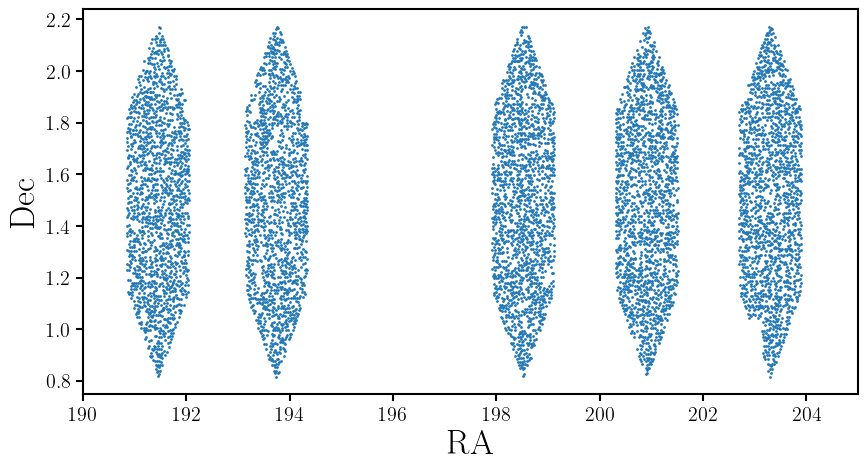

In [7]:
fig = plt.figure(figsize=(10,5))
sub = fig.add_subplot(111)
sub.scatter(kota['ra'], kota['dec'], c='C0', s=1)
sub.set_xlabel('RA', fontsize=25)
sub.set_xlim(190, 205)
sub.set_ylabel('Dec', fontsize=25)

Text(0, 0.5, 'Dec')

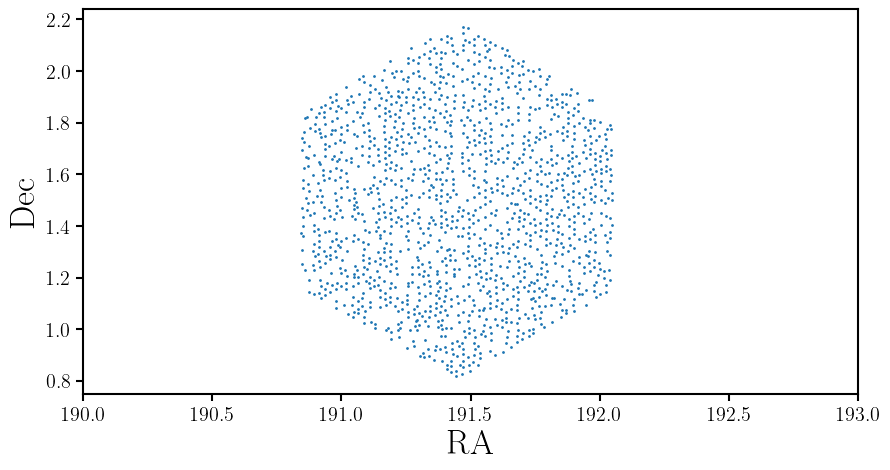

In [8]:
fig = plt.figure(figsize=(10,5))
sub = fig.add_subplot(111)
sub.scatter(kota['ra'], kota['dec'], c='C0', s=1)
sub.set_xlabel('RA', fontsize=25)
sub.set_xlim(190, 193)
sub.set_ylabel('Dec', fontsize=25)

In [9]:
# pass visual inspection criterion set by DESI Lan et al.(2022)
q_thresh = 3
pass_vi = 0.5*(kota['user1'] + kota['user2']) >= q_thresh
print('%.2f pass VI' % np.mean(pass_vi))
in_zrange = (kota['z_measured'] > 0.6) & (kota['z_measured'] < 2.4)
print('%.2f pass VI and 0.6 < z < 2.4' % np.mean(pass_vi & in_zrange))
highz = (kota['z_measured'] > 1.6) & (kota['z_measured'] < 2.4)
print('%.4f pass VI and 1.6 < z < 2.4' % np.mean(pass_vi & highz))

0.54 pass VI
0.52 pass VI and 0.6 < z < 2.4
0.0526 pass VI and 1.6 < z < 2.4


In [10]:
_zs, _ng = [], [] 
for zmin, zmax in zip([0.6, 0.8, 1., 1.2, 1.4, 1.6, 2.], [0.8, 1., 1.2, 1.4, 1.6, 2., 2.2]): 
    _zrange = (kota['z_measured'] > zmin) & (kota['z_measured'] < zmax)
    print('%.3f, %.1f, pass VI and %.1f < z < %.1f' % (np.mean(pass_vi & _zrange), np.mean(pass_vi & _zrange) * 1450., zmin, zmax))
    _zs.append(0.5*(zmin + zmax))
    _ng.append(np.mean(pass_vi & _zrange) * 1450.)

0.041, 60.0, pass VI and 0.6 < z < 0.8
0.129, 187.3, pass VI and 0.8 < z < 1.0
0.127, 184.0, pass VI and 1.0 < z < 1.2
0.110, 158.8, pass VI and 1.2 < z < 1.4
0.057, 82.6, pass VI and 1.4 < z < 1.6
0.038, 55.2, pass VI and 1.6 < z < 2.0
0.009, 13.4, pass VI and 2.0 < z < 2.2


Text(0.5, 0, 'redshift')

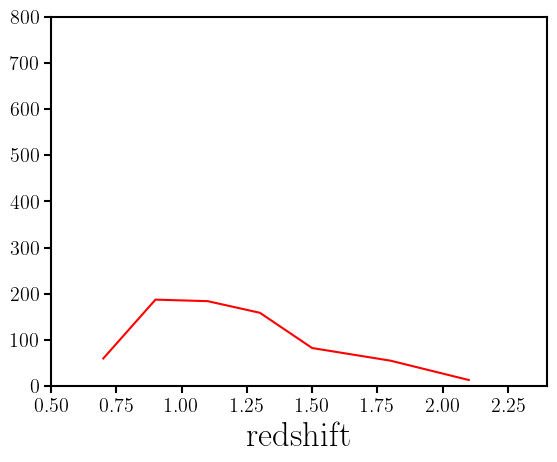

In [14]:
plt.plot(_zs, _ng, color='r')
plt.ylim(0., 800)
plt.xlim(0.5, 2.4)
plt.xlabel("redshift", fontsize=25)

In [15]:
g_mag = kota['g_cmodel_mag_2'] - kota['a_g']
r_mag = kota['r_cmodel_mag_2'] - kota['a_r']
i_mag = kota['i_cmodel_mag_2'] - kota['a_i']
z_mag = kota['z_cmodel_mag_2'] - kota['a_z']

In [16]:
# calculate comoving volume of 1 sq.deg
V_lowz = (1/41253. * (Planck18.comoving_volume(1.6) - Planck18.comoving_volume(0.6)) * Planck18.h**3).value
V_highz = (1/41253. * (Planck18.comoving_volume(2.4) - Planck18.comoving_volume(1.6)) * Planck18.h**3).value
print('low-z volume %.2e' % V_lowz)
print('high-z volume %.2e' % V_highz)

low-z volume 2.81e+06
high-z volume 3.10e+06


In [17]:
# sample the colormaps that you want to use. Use 128 from each so we get 256
# colors in total
clrs1 = plt.cm.Blues(np.linspace(0.5, 1, 20))
clrs2 = plt.cm.Spectral_r(np.linspace(0.2, 1, 80))

# combine them and build a new colormap
colors = np.vstack((clrs2, clrs1))
mymap = mpl.colors.LinearSegmentedColormap.from_list('my_colormap', colors)

Text(0, 0.5, '$N_{\\rm gal}$ (passed VI)')

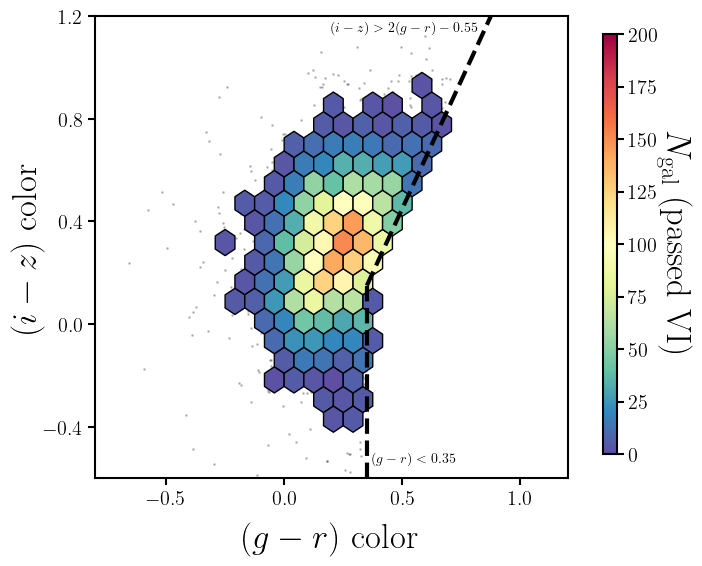

In [18]:
# (g-r) vs (i-z) figure
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)

sub.scatter(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    c='k', s=1, alpha=0.2)
hb = sub.hexbin(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    C=pass_vi.astype(float), 
    edgecolors='k', linewidth=1., reduce_C_function=np.sum, 
    extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=200, mincnt=5, cmap='Spectral_r')

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$N_{\rm gal}$ (passed VI)', labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, 'VI pass rate (Q $\\ge$ 3.0)')

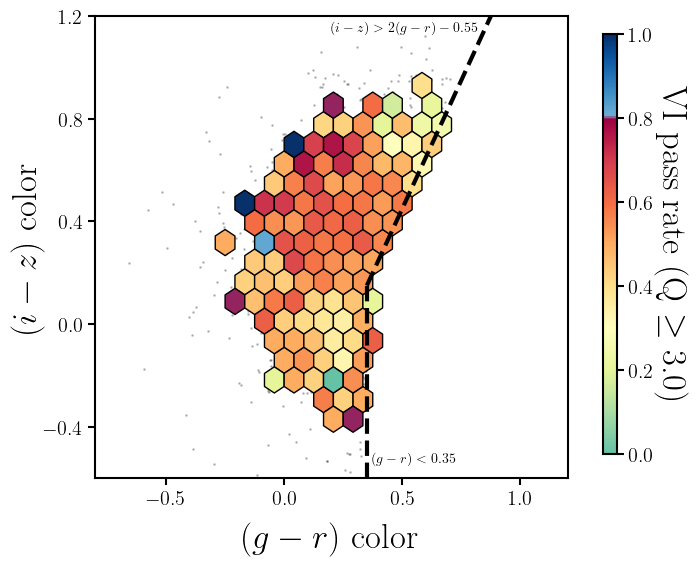

In [19]:
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)

sub.scatter(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    c='k', s=1, alpha=0.2)
hb = sub.hexbin(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    C=pass_vi.astype(float), 
    edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
    extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap=mymap)#'Spectral_r')

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'VI pass rate (Q $\ge$ %.1f)' % q_thresh, labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, '$z$ success rate')

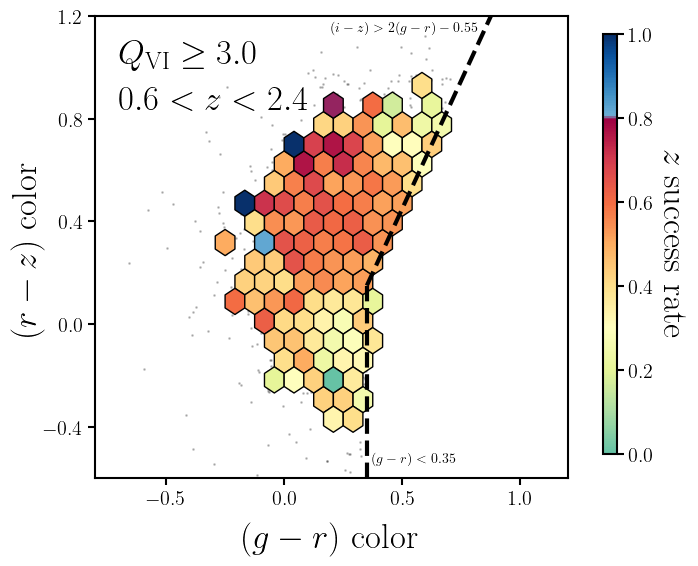

In [20]:
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)

sub.scatter(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    c='k', s=1, alpha=0.2)
hb = sub.hexbin(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    C=(pass_vi & in_zrange).astype(float), 
    edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
    extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap=mymap)#'Spectral_r')

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge %.1f$' % q_thresh, ha='left', va='top', transform=sub.transAxes, fontsize=25)
sub.text(0.05, 0.85, r'$0.6 < z < 2.4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(r - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$z$ success rate', labelpad=25, fontsize=25, rotation=270)

# $i$ magnitude dependence

0.6417525773195877
0.5690747782002535
0.48400520156046817
0.6125429553264605
0.5517532741867343
0.4657997399219766


Text(0, 0.5, '$z$ success rate')

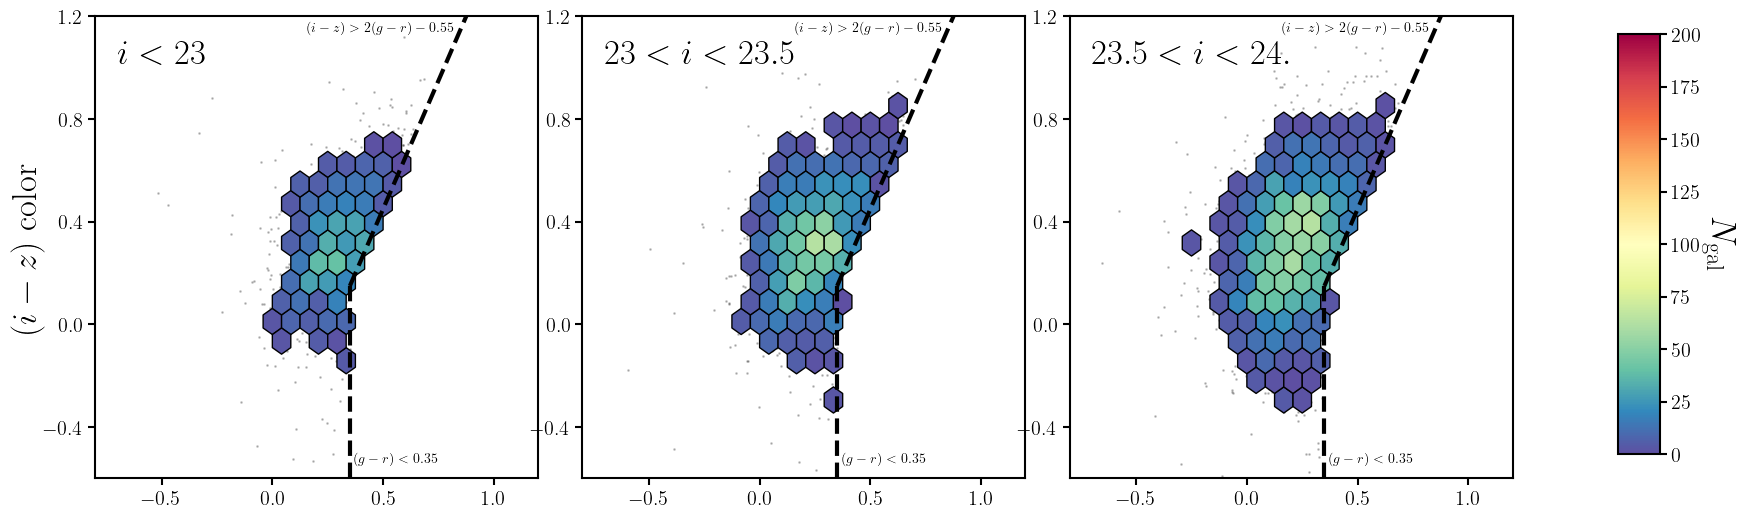

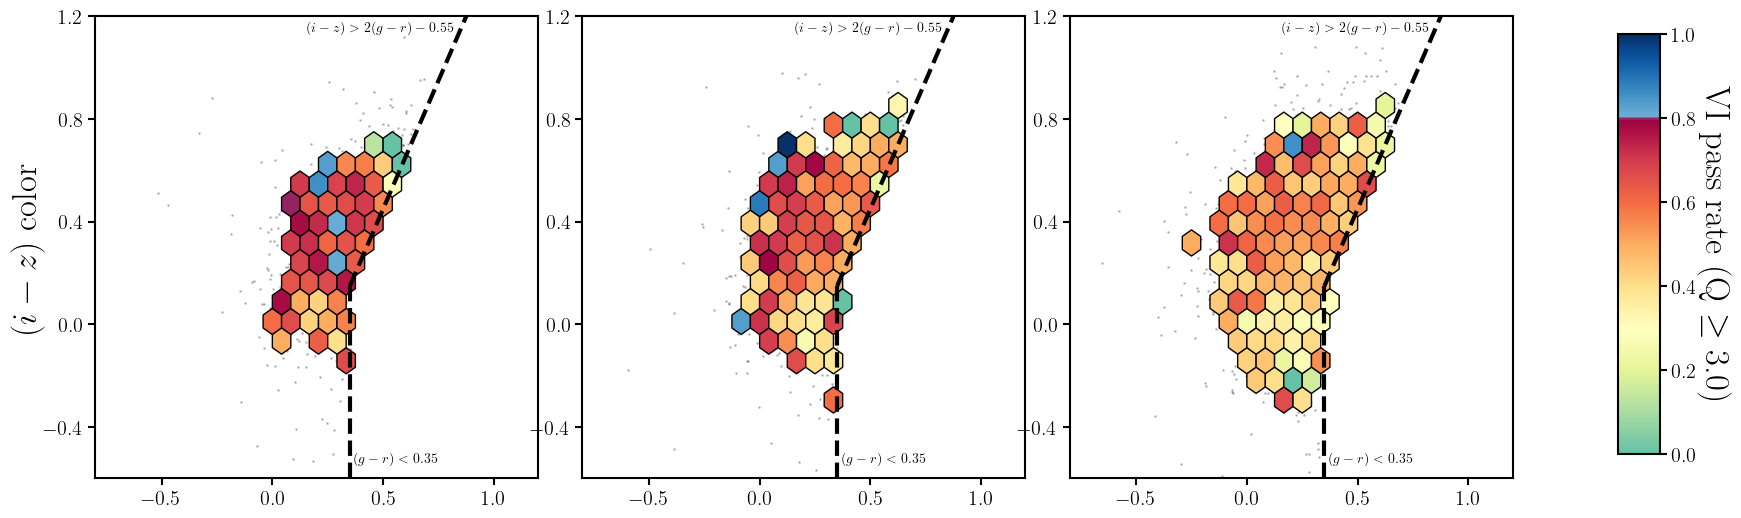

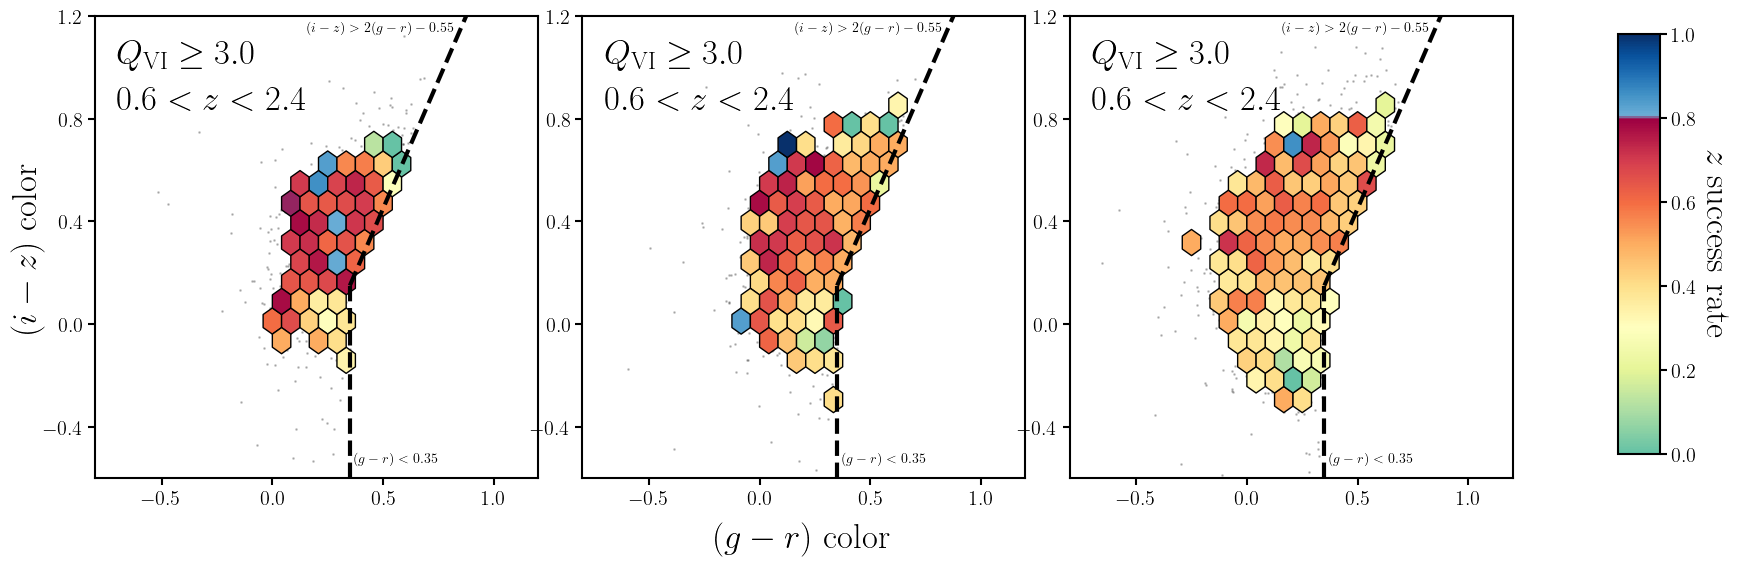

In [21]:
# (g-r) vs (i-z) figure
fig = plt.figure(figsize=(21,6))

for i in range(3): 
    sub = fig.add_subplot(1,3,i+1)

    imag_lim = [(i_mag < 23.), (i_mag >= 23.) & (i_mag < 23.5), (i_mag >= 23.5)][i]

    sub.scatter(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        c='k', s=1, alpha=0.2)
    hb = sub.hexbin(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        C=pass_vi.astype(float)[imag_lim], 
        edgecolors='k', linewidth=1., reduce_C_function=np.sum, 
        extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=200, mincnt=5, cmap='Spectral_r')
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

    sub.text(0.05, 0.95, [r'$i < 23$', r'$23 < i < 23.5$', r'$23.5 < i < 24.$'][i], 
             ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
#bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$N_{\rm gal}$', labelpad=25, fontsize=25, rotation=270)


fig = plt.figure(figsize=(21,6))

for i in range(3): 
    sub = fig.add_subplot(1,3,i+1)

    imag_lim = [(i_mag < 23.), (i_mag >= 23.) & (i_mag < 23.5), (i_mag >= 23.5)][i]

    sub.scatter(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        c='k', s=1, alpha=0.2)
    hb = sub.hexbin(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        C=pass_vi.astype(float)[imag_lim], 
        edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
        extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap=mymap)#'Spectral_r')
    print(np.mean((pass_vi).astype(float)[imag_lim]))
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
#bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'VI pass rate (Q $\ge$ %.1f)' % q_thresh, labelpad=25, fontsize=25, rotation=270)



fig = plt.figure(figsize=(21,6))
for i in range(3): 
    sub = fig.add_subplot(1,3,i+1)

    imag_lim = [(i_mag < 23.), (i_mag >= 23.) & (i_mag < 23.5), (i_mag >= 23.5)][i]

    sub.scatter(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        c='k', s=1, alpha=0.2)
    hb = sub.hexbin(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        C=(pass_vi & in_zrange).astype(float)[imag_lim], 
        edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
        extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap=mymap)#'Spectral_r')
    print(np.mean((pass_vi & in_zrange).astype(float)[imag_lim]))
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge %.1f$' % q_thresh, ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$0.6 < z < 2.4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$z$ success rate', labelpad=25, fontsize=25, rotation=270)

1196.706804816578 114.99299915989918
0.5717926932880204
1133.8640630867444 115.43372136687945
0.5445224985760395
1065.7860115451738 120.84306618338033
0.5165401301518439


Text(0, 0.5, '$z$ success rate')

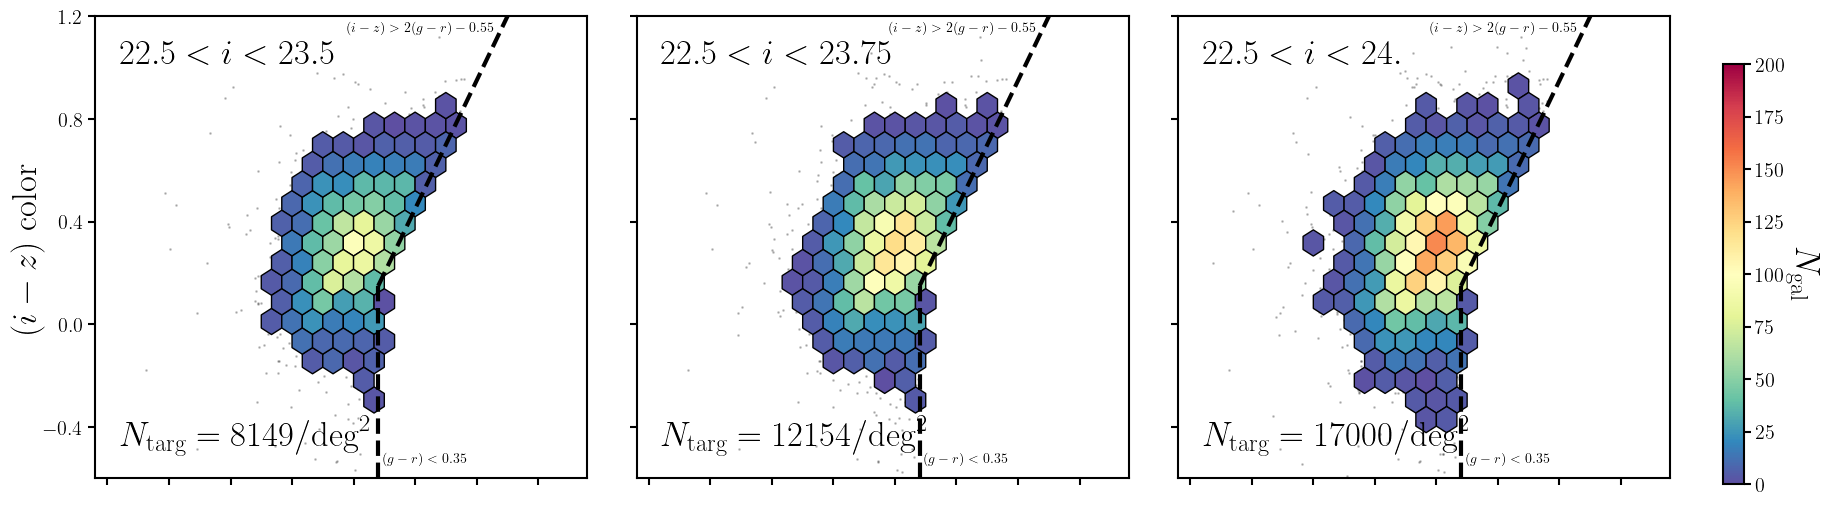

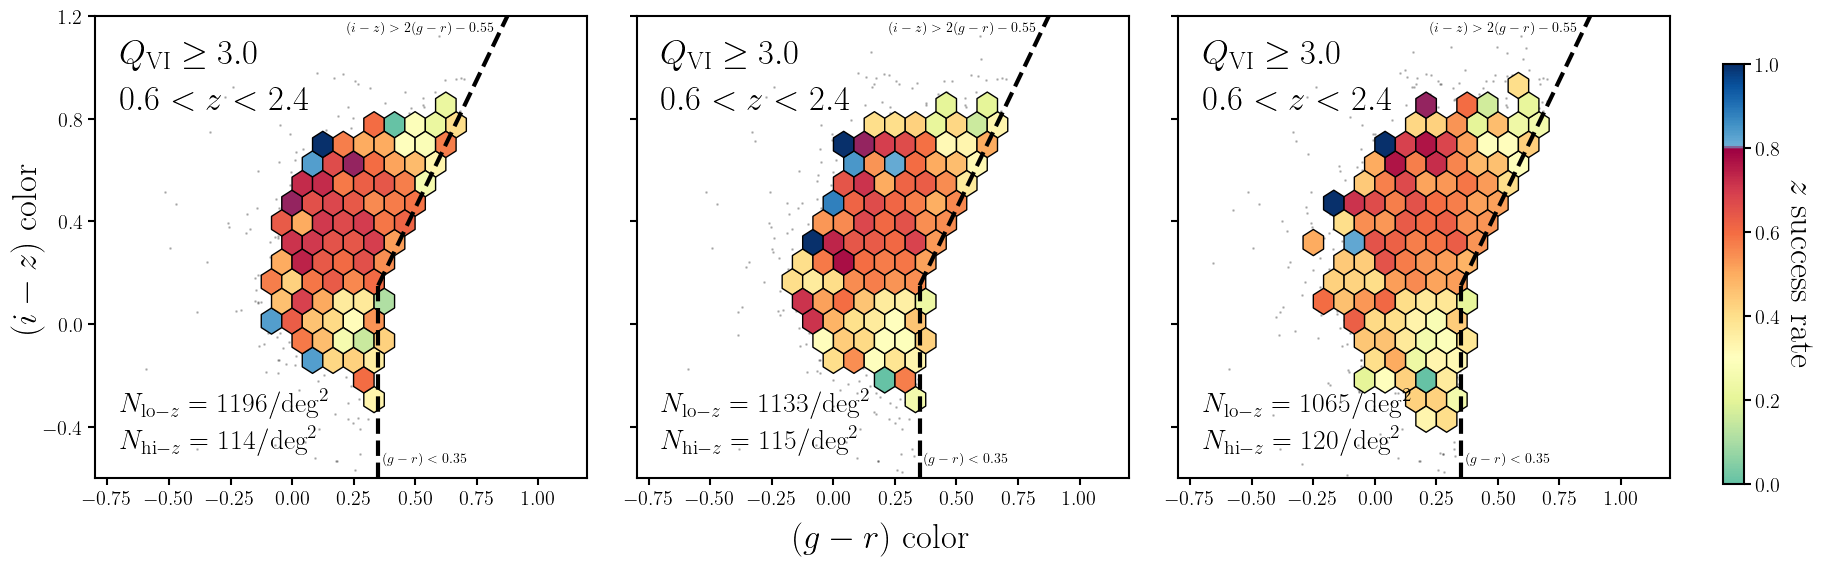

In [50]:
# (g-r) vs (i-z) figure
fig = plt.figure(figsize=(21,6))

for i in range(3): 
    sub = fig.add_subplot(1,3,i+1)

    imag_lim = [(i_mag < 23.5), (i_mag < 23.75), (i_mag < 24)][i]

    sub.scatter(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        c='k', s=1, alpha=0.2)
    hb = sub.hexbin(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        C=pass_vi.astype(float)[imag_lim], 
        edgecolors='k', linewidth=1., reduce_C_function=np.sum, 
        extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=200, mincnt=5, cmap='Spectral_r')
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

    sub.text(0.05, 0.95, [r'$22.5 < i < 23.5$', r'$22.5 < i < 23.75$', r'$22.5 < i < 24.$'][i], 
             ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.05, r'$N_{\rm targ} = %i/{\rm deg}^{2}$' % (17000. * np.sum(imag_lim)/len(i_mag)), 
             ha='left', va='bottom', transform=sub.transAxes, fontsize=25)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    if i > 0: sub.set_yticklabels([])
    sub.set_xticklabels([])
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
#bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.875)

cbar_ax = fig.add_axes([0.9, 0.1, 0.01, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$N_{\rm gal}$', labelpad=25, fontsize=25, rotation=270)


fig = plt.figure(figsize=(21,6))
for i in range(3): 
    sub = fig.add_subplot(1,3,i+1)

    imag_lim = [(i_mag < 23.5), (i_mag < 23.75), (i_mag < 24)][i]

    Ntarget = 17000. * np.mean(imag_lim)
    f_assign = np.clip((Ntarget - 3000.0)/17000. + 0.8, 0., 1.) # 0.97 @ 6000 and 0.8@3000
    _loz = (2900. / 1.25 * f_assign * (np.sum(imag_lim & pass_vi & (in_zrange & ~highz)) / np.sum(imag_lim)))
    _hiz = (2900. / 1.25 * f_assign * (np.sum(imag_lim & pass_vi & highz) / np.sum(imag_lim)))
    print(_loz, _hiz)
    
    sub.scatter(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        c='k', s=1, alpha=0.2)
    hb = sub.hexbin(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        C=(pass_vi & in_zrange).astype(float)[imag_lim], 
        edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
        extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap=mymap)#'Spectral_r')
    print(np.mean((pass_vi & in_zrange).astype(float)[imag_lim]))
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge %.1f$' % q_thresh, ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$0.6 < z < 2.4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

    sub.text(0.05, 0.13, r'$N_{{\rm lo}-z} = %i/{\rm deg}^{2}$' % _loz,
             ha='left', va='bottom', transform=sub.transAxes, fontsize=20)
    sub.text(0.05, 0.05, r'$N_{{\rm hi}-z} = %i/{\rm deg}^{2}$' % _hiz,
             ha='left', va='bottom', transform=sub.transAxes, fontsize=20)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    if i > 0: sub.set_yticklabels([])

    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.875)

cbar_ax = fig.add_axes([0.9, 0.1, 0.01, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$z$ success rate', labelpad=25, fontsize=25, rotation=270)

755.0775327194643 191.1114350803607
0.5519125683060109
731.1751551545049 211.5185270268389
0.501737317581654
762.5921512012087 233.88779895088618
0.4751640112464855


Text(0, 0.5, '$z$ success rate')

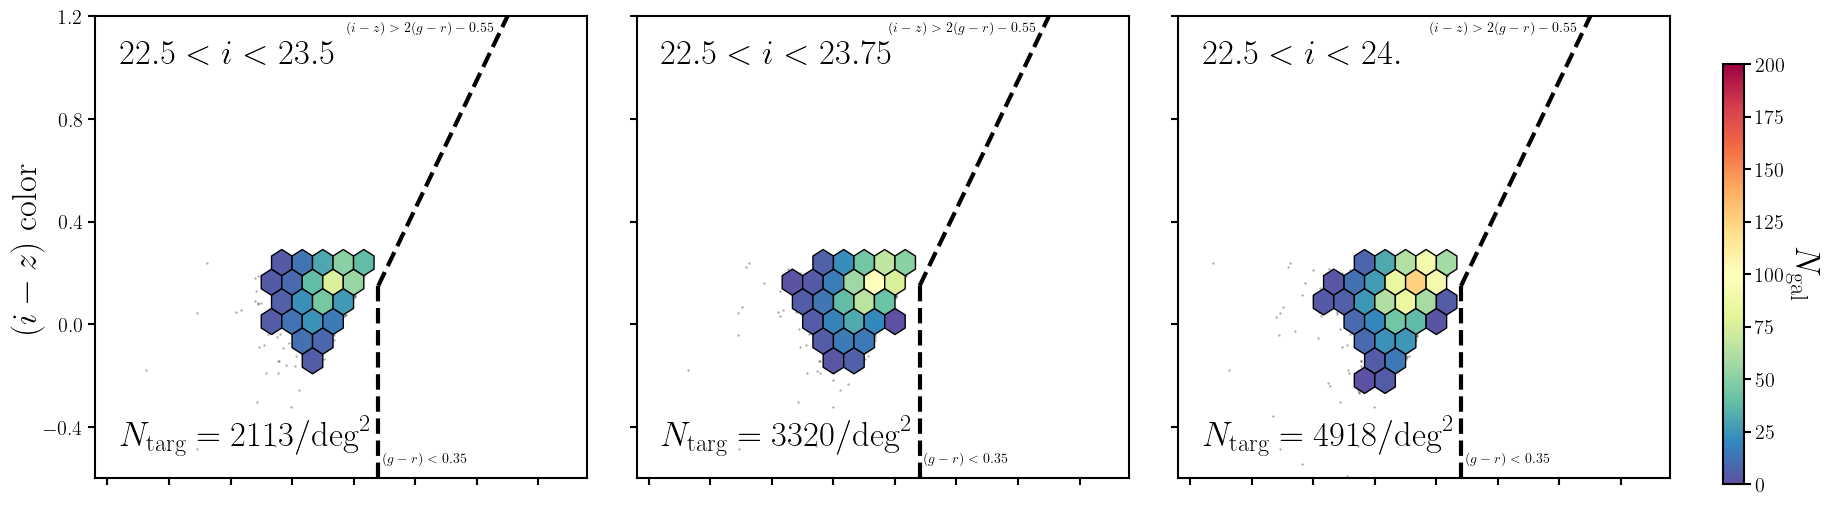

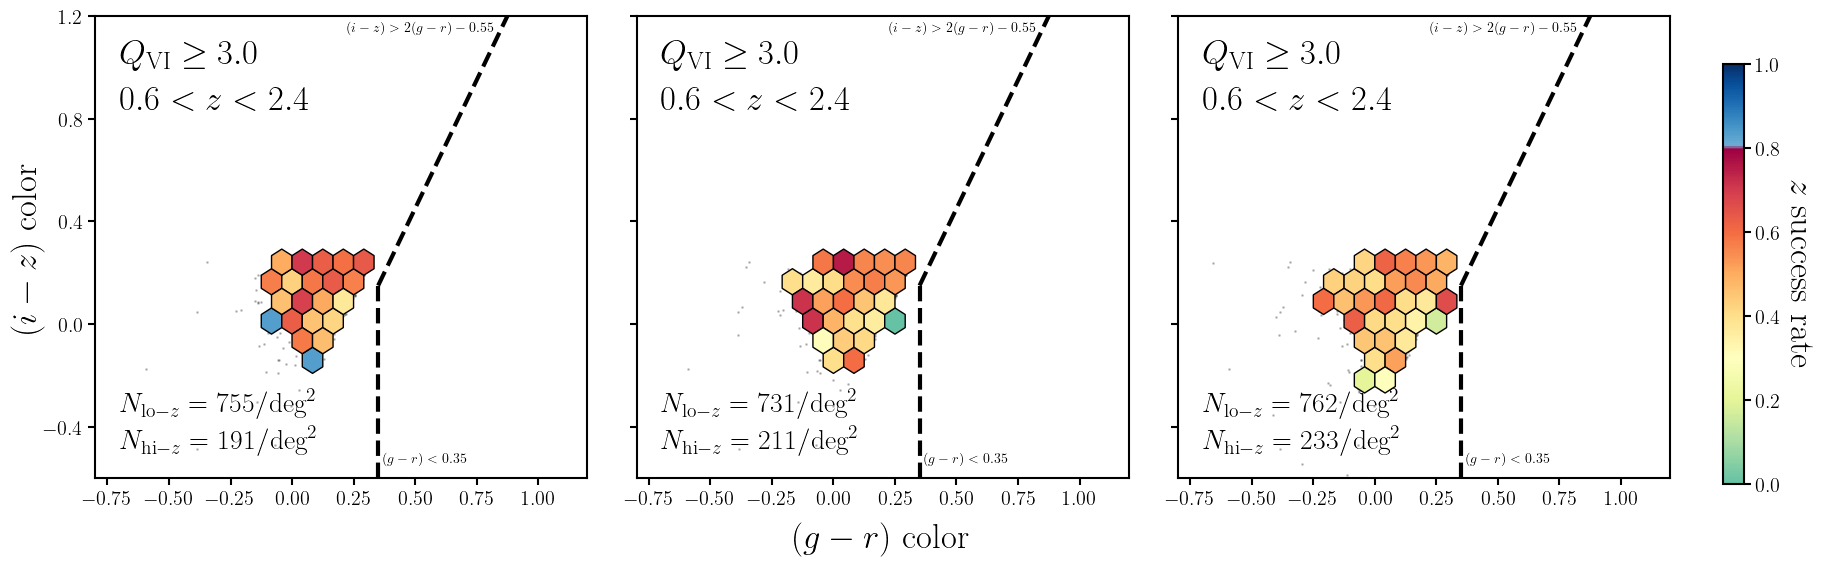

In [51]:
agg_cut = (((i_mag - z_mag) > 2*(g_mag - r_mag) - 0.4) & ((i_mag - z_mag) < 0.25))

# (g-r) vs (i-z) figure
fig = plt.figure(figsize=(21,6))

for i in range(3): 
    sub = fig.add_subplot(1,3,i+1)

    imag_lim = [(i_mag < 23.5), (i_mag < 23.75), (i_mag < 24)][i] & agg_cut

    sub.scatter(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        c='k', s=1, alpha=0.2)
    hb = sub.hexbin(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        C=pass_vi.astype(float)[imag_lim], 
        edgecolors='k', linewidth=1., reduce_C_function=np.sum, 
        extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=200, mincnt=5, cmap='Spectral_r')
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

    sub.text(0.05, 0.95, [r'$22.5 < i < 23.5$', r'$22.5 < i < 23.75$', r'$22.5 < i < 24.$'][i], 
             ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.05, r'$N_{\rm targ} = %i/{\rm deg}^{2}$' % (17000. * np.sum(imag_lim)/len(i_mag)), 
             ha='left', va='bottom', transform=sub.transAxes, fontsize=25)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    if i > 0: sub.set_yticklabels([])
    sub.set_xticklabels([])
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
#bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.875)

cbar_ax = fig.add_axes([0.9, 0.1, 0.01, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$N_{\rm gal}$', labelpad=25, fontsize=25, rotation=270)


fig = plt.figure(figsize=(21,6))
for i in range(3): 
    sub = fig.add_subplot(1,3,i+1)

    imag_lim = [(i_mag < 23.5), (i_mag < 23.75), (i_mag < 24)][i] & agg_cut

    Ntarget = 17000. * np.mean(imag_lim)
    f_assign = np.clip((Ntarget - 3000.0)/17000. + 0.8, 0., 1.) # 0.97 @ 6000 and 0.8@3000
    _loz = (2900. / 1.25 * f_assign * (np.sum(imag_lim & pass_vi & (in_zrange & ~highz)) / np.sum(imag_lim)))
    _hiz = (2900. / 1.25 * f_assign * (np.sum(imag_lim & pass_vi & highz) / np.sum(imag_lim)))
    print(_loz, _hiz)
    
    sub.scatter(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        c='k', s=1, alpha=0.2)
    hb = sub.hexbin(
        (g_mag - r_mag)[imag_lim], # (g-r)
        (i_mag - z_mag)[imag_lim], # (i-z)
        C=(pass_vi & in_zrange).astype(float)[imag_lim], 
        edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
        extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap=mymap)#'Spectral_r')
    print(np.mean((pass_vi & in_zrange).astype(float)[imag_lim]))
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge %.1f$' % q_thresh, ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$0.6 < z < 2.4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

    sub.text(0.05, 0.13, r'$N_{{\rm lo}-z} = %i/{\rm deg}^{2}$' % _loz,
             ha='left', va='bottom', transform=sub.transAxes, fontsize=20)
    sub.text(0.05, 0.05, r'$N_{{\rm hi}-z} = %i/{\rm deg}^{2}$' % _hiz,
             ha='left', va='bottom', transform=sub.transAxes, fontsize=20)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    if i > 0: sub.set_yticklabels([])

    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.875)

cbar_ax = fig.add_axes([0.9, 0.1, 0.01, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$z$ success rate', labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, 'median $z$')

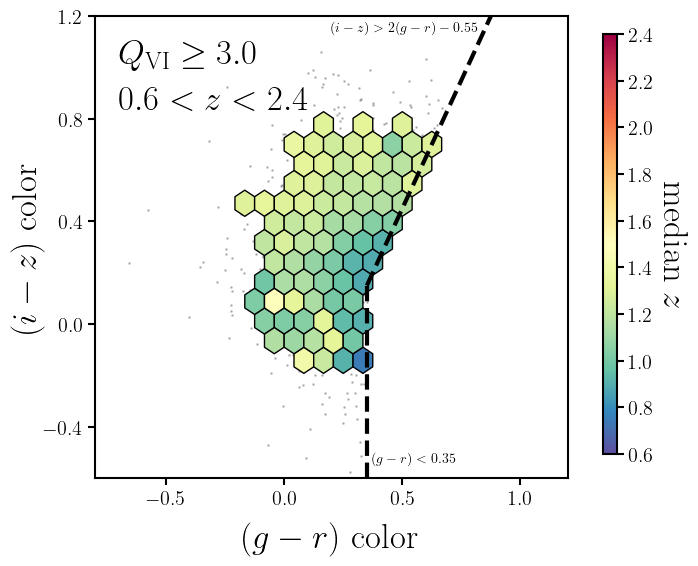

In [17]:
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)

sub.scatter(
    (g_mag - r_mag)[pass_vi & in_zrange], # (g-r)
    (i_mag - z_mag)[pass_vi & in_zrange], # (i-z)
    c='k', s=1, alpha=0.2)
hb = sub.hexbin(
    (g_mag - r_mag)[pass_vi & in_zrange], # (g-r)
    (i_mag - z_mag)[pass_vi & in_zrange], # (i-z)
    C=kota['z_measured'][pass_vi & in_zrange], 
    edgecolors='k', linewidth=1., reduce_C_function=np.median, 
    extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0.6, vmax=2.4, mincnt=5, cmap='Spectral_r')

sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge %.1f$' % q_thresh, ha='left', va='top', transform=sub.transAxes, fontsize=25)
sub.text(0.05, 0.85, r'$0.6 < z < 2.4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'median $z$', labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, '$z$')

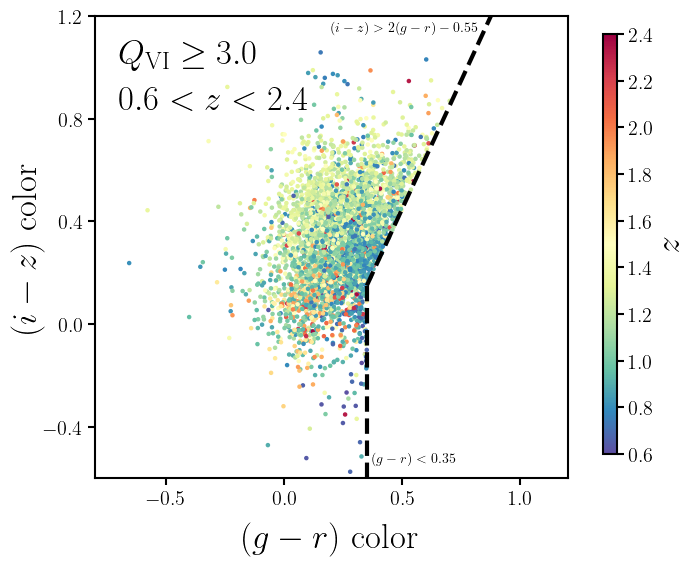

In [18]:
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)

hb = sub.scatter(
    (g_mag - r_mag)[pass_vi & in_zrange], # (g-r)
    (i_mag - z_mag)[pass_vi & in_zrange], # (i-z)
    c=kota['z_measured'][pass_vi & in_zrange], s=5, vmin=0.6, vmax=2.4, cmap='Spectral_r')

sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge %.1f$' % q_thresh, ha='left', va='top', transform=sub.transAxes, fontsize=25)
sub.text(0.05, 0.85, r'$0.6 < z < 2.4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$z$', labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, '$z$')

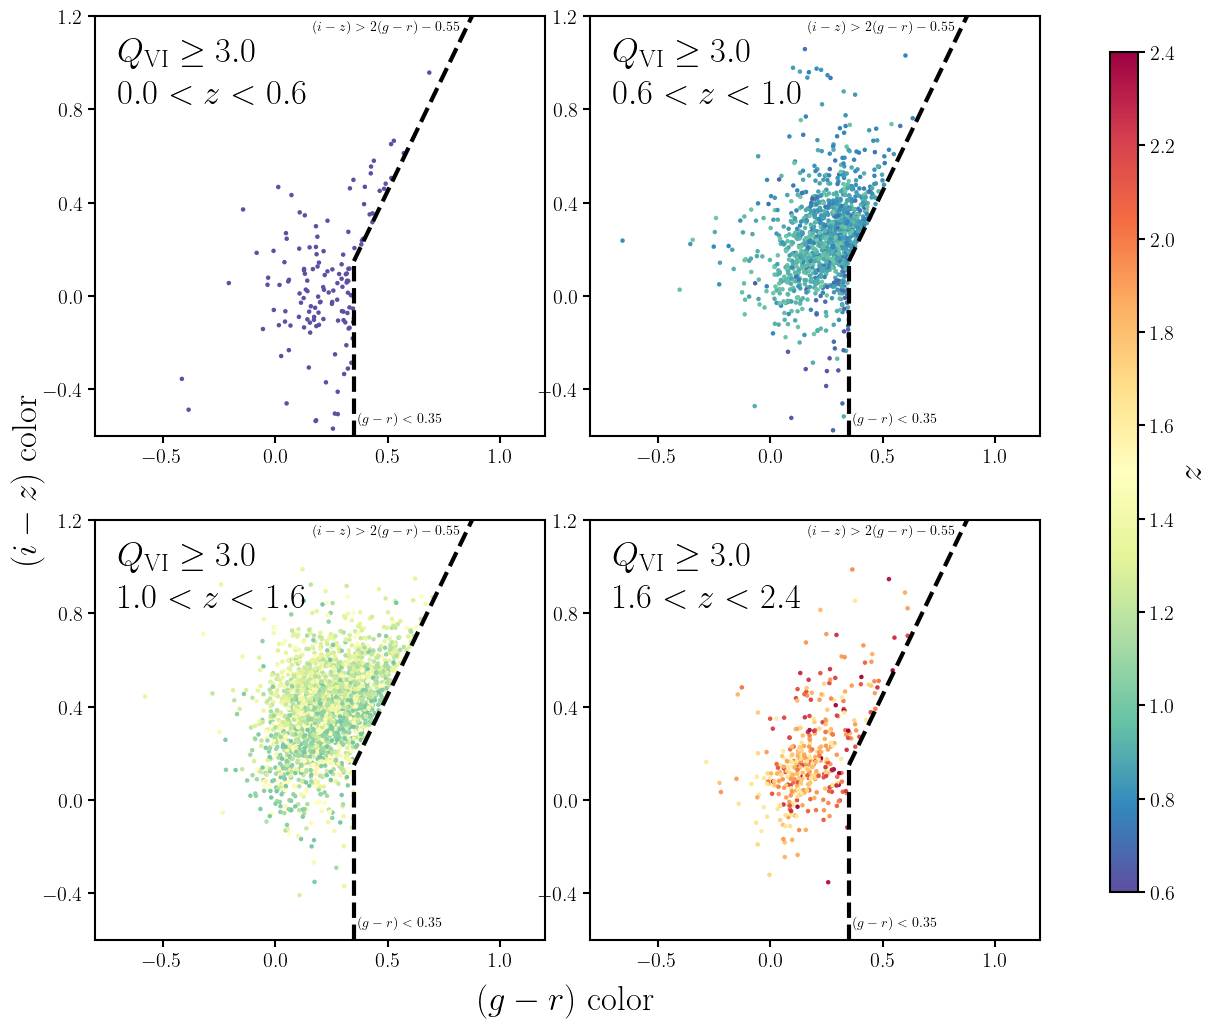

In [19]:
fig = plt.figure(figsize=(14, 12))
for i in range(4): 
    sub = fig.add_subplot(2,2,i+1)

    zlim = (kota['z_measured'] > [0, 0.6, 1., 1.6][i]) & (kota['z_measured'] < [0.6, 1., 1.6, 2.4][i])
    hb = sub.scatter(
        (g_mag - r_mag)[pass_vi & zlim], # (g-r)
        (i_mag - z_mag)[pass_vi & zlim], # (i-z)
        c=kota['z_measured'][pass_vi & zlim], s=5, vmin=0.6, vmax=2.4, cmap='Spectral_r')

    # sub.hexbin(
    #     (g_mag - r_mag)[pass_vi & zlim], # (g-r)
    #     (i_mag - z_mag)[pass_vi & zlim], # (i-z)
    #     C=np.ones(np.sum(pass_vi & in_zrange)),
    #     edgecolors='k', linewidth=1., reduce_C_function=np.sum, 
    #     extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0, vmax=100, mincnt=5, cmap='Greys_r')
    
    
    sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge %.1f$' % q_thresh, ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0, 0.6, 1., 1.6][i], [0.6, 1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$z$', labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, 'fraction with $z > 1.6$')

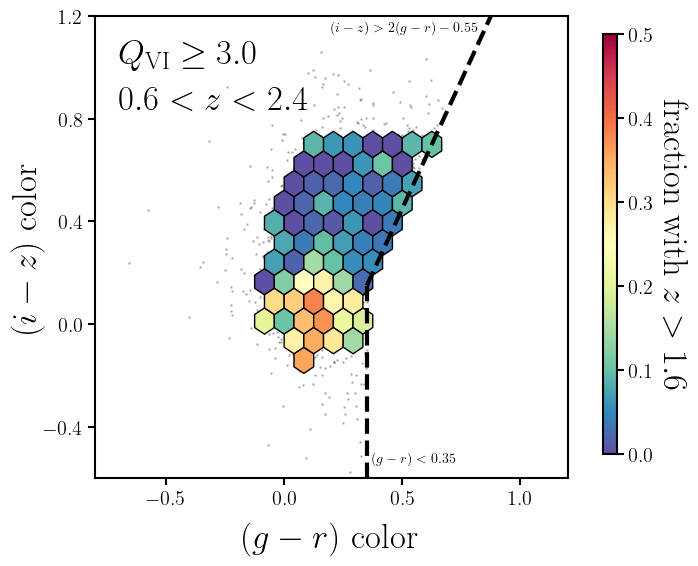

In [23]:
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)

sub.scatter(
    (g_mag - r_mag)[pass_vi & in_zrange], # (g-r)
    (i_mag - z_mag)[pass_vi & in_zrange], # (i-z)
    c='k', s=1, alpha=0.2)
hb = sub.hexbin(
    (g_mag - r_mag)[pass_vi & in_zrange], # (g-r)
    (i_mag - z_mag)[pass_vi & in_zrange], # (i-z)
    C=(kota['z_measured'][pass_vi & in_zrange] > 1.6), 
    edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
    extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=0.5, mincnt=10, cmap='Spectral_r')

sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge %.1f$' % q_thresh, ha='left', va='top', transform=sub.transAxes, fontsize=25)
sub.text(0.05, 0.85, r'$0.6 < z < 2.4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'fraction with $z > 1.6$', labelpad=25, fontsize=25, rotation=270)

At the end of the day, how many will we have in our LSS catalog

In [43]:
# this strategy has target density of 17,000 objects/deg^2 (i.e. super fiber efficient >97%)
passes = (2900.0 / 1.25 * # 2 passes with 1450 science fibers 1.25 deg^2 FOV
          0.97 * # >97% fiber efficiency
          np.mean(pass_vi & highz))
print('%.3f objects per sq.deg.' % passes)
print('%.3e 1.6 < z < 2.4 objects per (Mpc/h)^3' % (passes / V_highz))

118.378 objects per sq.deg.
3.817e-05 1.6 < z < 2.4 objects per (Mpc/h)^3


# check more aggressive cut

In [54]:
# pass visual inspection criterion set by DESI Lan et al.(2022)
q_thresh = 3
pass_vi = 0.5*(kota['user1'] + kota['user2']) >= q_thresh

In [55]:
agg_cut = (((i_mag - z_mag) > 2*(g_mag - r_mag) - 0.4) & ((i_mag - z_mag) < 0.25))

In [56]:
print(np.mean(agg_cut))

0.28930057725869246


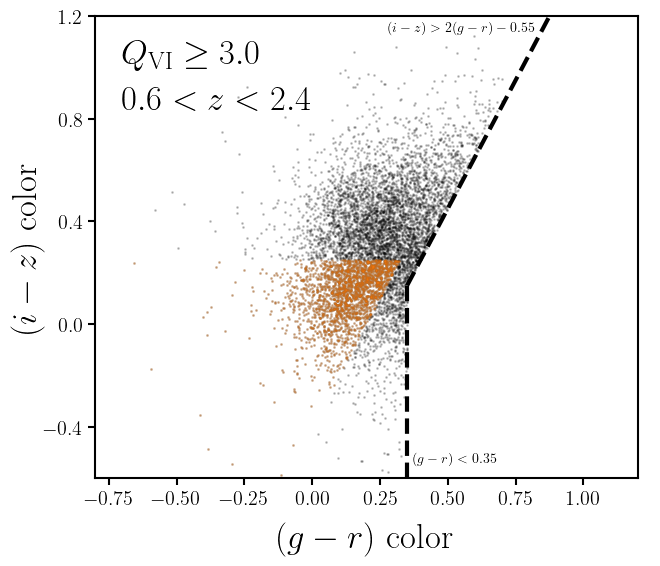

In [58]:
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)

sub.scatter(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    c='k', s=1, alpha=0.2)

sub.scatter(
    (g_mag - r_mag)[agg_cut], # (g-r)
    (i_mag - z_mag)[agg_cut], # (i-z)
    c='C1', s=1, alpha=0.2)


sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge %.1f$' % q_thresh, ha='left', va='top', transform=sub.transAxes, fontsize=25)
sub.text(0.05, 0.85, r'$0.6 < z < 2.4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
# fig.subplots_adjust(wspace=0.1, right=0.8)

# cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
# cbar = fig.colorbar(hb, cax=cbar_ax)
# cbar.ax.set_ylabel(r'median $z$', labelpad=25, fontsize=25, rotation=270)

In [59]:
print('%.3f pass VI' % (np.sum(agg_cut & pass_vi)/np.sum(agg_cut)))
print('%.3f pass VI' % (np.sum(agg_cut & pass_vi & in_zrange)/np.sum(agg_cut)))
print('%.3f pass VI' % (np.sum(agg_cut & pass_vi & highz)/np.sum(agg_cut)))

0.492 pass VI
0.471 pass VI
0.110 pass VI


In [64]:
f_assign

np.float64(0.9128299890233984)

In [61]:
Ntarget = 17000 * np.mean(agg_cut) # target/deg^2
f_assign = np.clip((Ntarget - 3000.0)/17000. + 0.8, 0., 1.) # 0.97 @ 6000 and 0.8@3000
passes = (2900. / 1.25 * f_assign * (np.sum(agg_cut & pass_vi & highz) / np.sum(agg_cut)))

print('%.3f objects per sq.deg.' % passes)
print('%.3e 1.6 < z < 2.4 objects per (Mpc/h)^3' % (passes / V_highz))

233.888 objects per sq.deg.
7.542e-05 1.6 < z < 2.4 objects per (Mpc/h)^3


In [66]:
# references
Ntarget = 17000  # target/deg^2
f_assign = np.clip((Ntarget - 3000.0)/17000. + 0.8, 0., 1.) # 0.97 @ 6000 and 0.8@3000
passes = (2900. / 1.25 * f_assign * np.mean(pass_vi & highz))
print('reference:')
print('%.3e 1.6 < z < 2.4 objects per (Mpc/h)^3' % (passes / V_highz))
print()

for i in range(11): 
    for j in range(11): 
        agg_cut = (((i_mag - z_mag) > 2*(g_mag - r_mag) - (0.55 - 0.015*i)) & ((i_mag - z_mag) < (0.4 - 0.05 * j)))
        if np.mean(agg_cut) < 0.35: continue

        Ntarget = 17000 * np.mean(agg_cut) # target/deg^2
        f_assign = np.clip((Ntarget - 3000.0)/17000. + 0.8, 0., 1.) # 0.97 @ 6000 and 0.8@3000
        passes = (2900. / 1.25 * f_assign * (np.sum(agg_cut & pass_vi & highz) / np.sum(agg_cut)))

        print('%.3f, %.2f, %.3e objects per (Mpc/h)^3 --- high-z success rate %.3f' % 
              ((0.55 - 0.015*i), (0.4 - 0.05 * j), passes/V_highz, (np.sum(agg_cut & pass_vi & highz) / np.sum(agg_cut))))

reference:
3.935e-05 1.6 < z < 2.4 objects per (Mpc/h)^3

0.550, 0.40, 5.106e-05 objects per (Mpc/h)^3 --- high-z success rate 0.068
0.550, 0.35, 5.661e-05 objects per (Mpc/h)^3 --- high-z success rate 0.076
0.550, 0.30, 6.429e-05 objects per (Mpc/h)^3 --- high-z success rate 0.086
0.550, 0.25, 7.163e-05 objects per (Mpc/h)^3 --- high-z success rate 0.097
0.535, 0.40, 5.158e-05 objects per (Mpc/h)^3 --- high-z success rate 0.069
0.535, 0.35, 5.747e-05 objects per (Mpc/h)^3 --- high-z success rate 0.077
0.535, 0.30, 6.517e-05 objects per (Mpc/h)^3 --- high-z success rate 0.087
0.535, 0.25, 7.181e-05 objects per (Mpc/h)^3 --- high-z success rate 0.098
0.520, 0.40, 5.166e-05 objects per (Mpc/h)^3 --- high-z success rate 0.069
0.520, 0.35, 5.762e-05 objects per (Mpc/h)^3 --- high-z success rate 0.077
0.520, 0.30, 6.529e-05 objects per (Mpc/h)^3 --- high-z success rate 0.087
0.520, 0.25, 7.146e-05 objects per (Mpc/h)^3 --- high-z success rate 0.098
0.505, 0.40, 5.220e-05 objects per (Mpc/h)

What if we play around with the magnitude cut

In [67]:
scenario = (((i_mag - z_mag) > 2*(g_mag - r_mag) - 0.53) & ((i_mag - z_mag) < 0.4))

for i in range(10): 
    mag_lim = (i_mag < 24. - 0.01*i)
    if np.mean(mag_lim & scenario) < 0.35: continue
    
    Ntarget = 17000 * np.mean(mag_lim & scenario) # target/deg^2
    f_assign = np.clip((Ntarget - 3000.0)/17000. + 0.8, 0., 1.) # 0.97 @ 6000 and 0.8@3000
    passes = (2900. / 1.25 * f_assign * (np.sum(mag_lim & scenario & pass_vi & highz) / np.sum(mag_lim & scenario)))
    
    print('i < %.1f, %.3e objects per (Mpc/h)^3' % (24.-0.05*i, passes/V_highz))

i < 24.0, 5.194e-05 objects per (Mpc/h)^3
i < 23.9, 5.153e-05 objects per (Mpc/h)^3
i < 23.9, 5.162e-05 objects per (Mpc/h)^3
i < 23.9, 5.115e-05 objects per (Mpc/h)^3
i < 23.8, 5.115e-05 objects per (Mpc/h)^3
i < 23.8, 5.122e-05 objects per (Mpc/h)^3
i < 23.7, 5.124e-05 objects per (Mpc/h)^3
i < 23.6, 5.104e-05 objects per (Mpc/h)^3
i < 23.6, 5.107e-05 objects per (Mpc/h)^3
i < 23.6, 5.040e-05 objects per (Mpc/h)^3


reference:
3.935e-05 1.6 < z < 2.4 objects per (Mpc/h)^3
3.471e-04 0.6 < z < 1.6 objects per (Mpc/h)^3

0.400, 0.20, Ntarget = 3.8e+03, f_assign=0.846, z-success rate 0.473, high-z success rate 0.127
low z --- 2.233e-04 objects per (Mpc/h)^3
high z --- 8.014e-05 objects per (Mpc/h)^3
wasted observations --- 61.284 percent


/var/folders/w7/p2lcz8lj0m39n1ywl2_s0_j40000gp/T/ipykernel_97560/2121421279.py:86: UserWarning: Adding colorbar to a different Figure <Figure size 1400x1200 with 6 Axes> than <Figure size 700x600 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(hb, cax=cbar_ax)


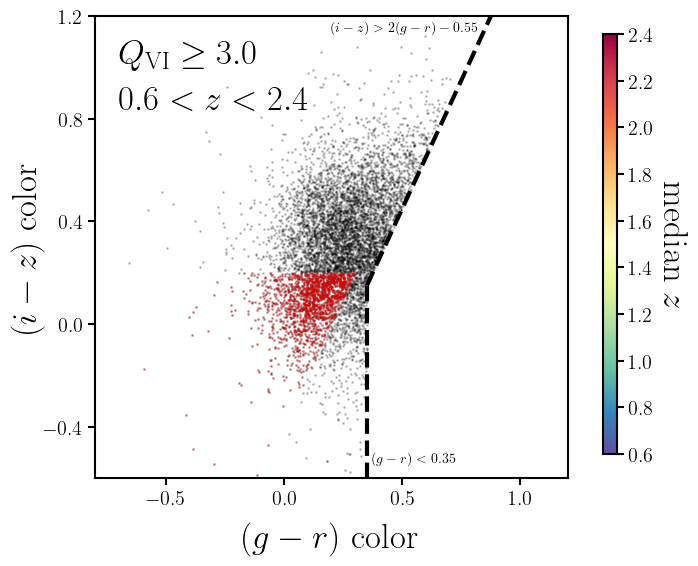

0.415, 0.20, Ntarget = 3.9e+03, f_assign=0.852, z-success rate 0.470, high-z success rate 0.123
low z --- 2.249e-04 objects per (Mpc/h)^3
high z --- 7.864e-05 objects per (Mpc/h)^3
wasted observations --- 61.304 percent


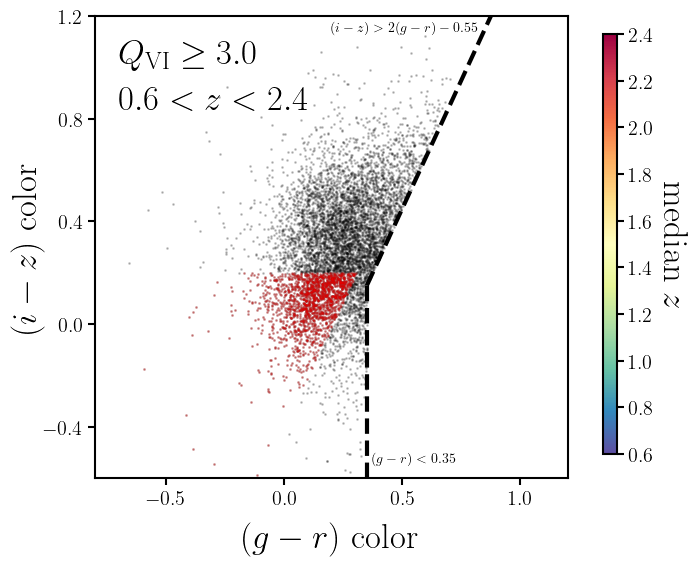

0.430, 0.20, Ntarget = 4.0e+03, f_assign=0.859, z-success rate 0.470, high-z success rate 0.122
low z --- 2.271e-04 objects per (Mpc/h)^3
high z --- 7.810e-05 objects per (Mpc/h)^3
wasted observations --- 61.132 percent


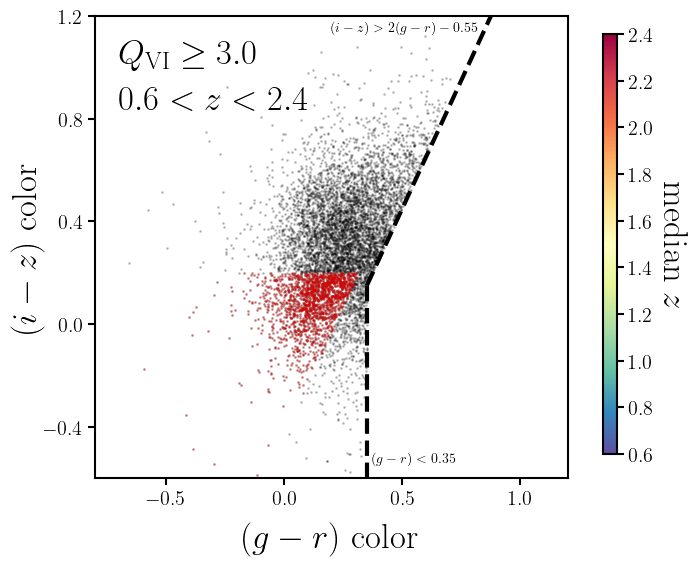

0.400, 0.15, Ntarget = 2.8e+03, f_assign=0.787, z-success rate 0.457, high-z success rate 0.132
low z --- 1.899e-04 objects per (Mpc/h)^3
high z --- 7.793e-05 objects per (Mpc/h)^3
wasted observations --- 65.579 percent


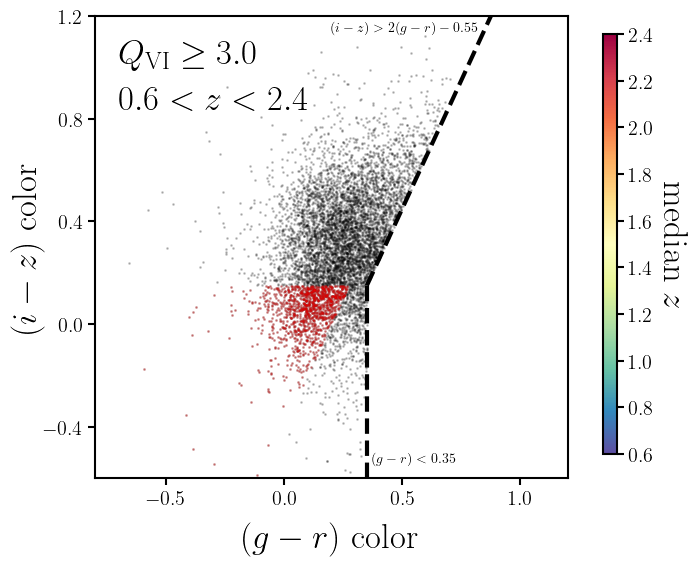

0.445, 0.20, Ntarget = 4.1e+03, f_assign=0.866, z-success rate 0.467, high-z success rate 0.120
low z --- 2.280e-04 objects per (Mpc/h)^3
high z --- 7.745e-05 objects per (Mpc/h)^3
wasted observations --- 61.032 percent


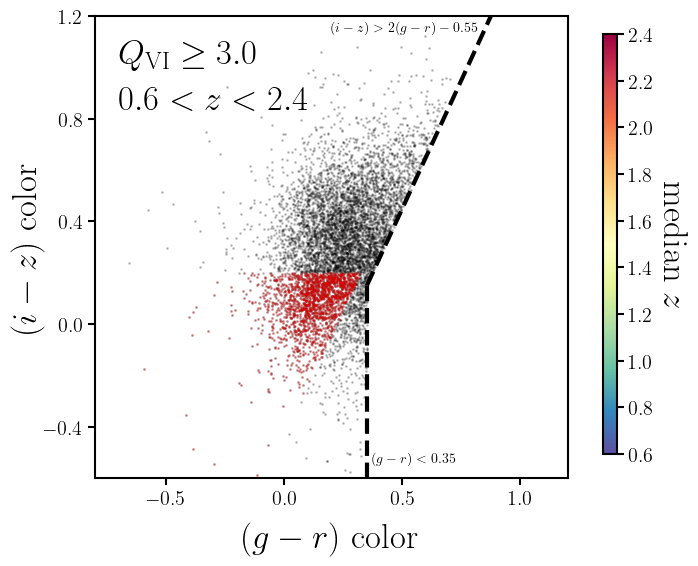

In [69]:
# pass visual inspection criterion set by DESI Lan et al.(2022)
q_thresh = 3
pass_vi = 0.5*(kota['user1'] + kota['user2']) >= q_thresh

# assuming 1450 science fibers
Ntarget = 17000  # target/deg^2
f_assign = np.clip((Ntarget - 3000.0)/17000. + 0.8, 0., 1.) # 0.97 @ 6000 and 0.8@3000
passes = (2900. / 1.25 * f_assign * np.mean(pass_vi & highz))
lowz = (2900. / 1.25 * f_assign * np.mean(pass_vi & in_zrange & ~highz))

print('reference:')
print('%.3e 1.6 < z < 2.4 objects per (Mpc/h)^3' % (passes / V_highz))
print('%.3e 0.6 < z < 1.6 objects per (Mpc/h)^3' % (lowz / V_highz))
print()


num_den, ij = [], []
for i in range(11): 
    for j in range(11): 
        agg_cut = (((i_mag - z_mag) > 2*(g_mag - r_mag) - (0.55 - 0.015*i)) & ((i_mag - z_mag) < (0.4 - 0.05 * j)))

        Ntarget = 17000 * np.mean(agg_cut) # target/deg^2
        f_assign = np.clip((Ntarget - 3000.0)/17000. + 0.8, 0., 1.) # 0.97 @ 6000 and 0.8@3000
        
        pass1and2 = (2900. / 1.25 * f_assign * (np.sum(agg_cut & pass_vi & highz) / np.sum(agg_cut)))
        num_den.append(pass1and2)
        ij.append([i,j])

for _i in np.argsort(num_den)[::-1][:5]: 
    i = ij[_i][0]
    j = ij[_i][1]

    agg_cut = (((i_mag - z_mag) > 2*(g_mag - r_mag) - (0.55 - 0.015*i)) & ((i_mag - z_mag) < (0.4 - 0.05 * j)))

    Ntarget = 17000 * np.mean(agg_cut) # target/deg^2
    f_assign = np.clip((Ntarget - 3000.0)/17000. + 0.8, 0., 1.) # 0.97 @ 6000 and 0.8@3000

    pass1and2 = (2900. / 1.25 * f_assign * (np.sum(agg_cut & pass_vi & highz) / np.sum(agg_cut)))


    print('%.3f, %.2f, Ntarget = %.1e, f_assign=%.3f, z-success rate %.3f, high-z success rate %.3f' % 
          ((0.55 - 0.015*i), (0.4 - 0.05 * j), Ntarget, f_assign, (np.sum(agg_cut & pass_vi) / np.sum(agg_cut)),(np.sum(agg_cut & pass_vi & highz) / np.sum(agg_cut))))
    
    lowz = (2900. / 1.25 * f_assign * (np.sum(agg_cut & pass_vi & in_zrange & ~highz) / np.sum(agg_cut)))

    waste = ((1-f_assign) + # unassigned fibers
             (f_assign * (np.sum(agg_cut & (~pass_vi | ~in_zrange)) / np.sum(agg_cut))))
             
    print("low z --- %.3e objects per (Mpc/h)^3" % (lowz / V_lowz))
    print("high z --- %.3e objects per (Mpc/h)^3" % (pass1and2 / V_highz))
    print('wasted observations --- %.3f percent' % (100*waste))
    
    fig = plt.figure(figsize=(7,6))
    sub = fig.add_subplot(111)
    
    sub.scatter(
        (g_mag - r_mag), # (g-r)
        (i_mag - z_mag), # (i-z)
        c='k', s=1, alpha=0.2)
    
    sub.scatter(
        (g_mag - r_mag)[agg_cut], # (g-r)
        (i_mag - z_mag)[agg_cut], # (i-z)
        c='r', s=1, alpha=0.2)
    
    
    sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge %.1f$' % q_thresh, ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$0.6 < z < 2.4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])
    
    bkgd = fig.add_subplot(111, frameon=False)
    bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
    bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
    bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    fig.subplots_adjust(wspace=0.1, right=0.8)
    
    cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(hb, cax=cbar_ax)
    cbar.ax.set_ylabel(r'median $z$', labelpad=25, fontsize=25, rotation=270)
    plt.show()

# check fiberid dependence

In [52]:
barhist = []
for fid in np.unique(kota['fiber_id']): 
    barhist.append([fid, np.mean((pass_vi & in_zrange)[kota['fiber_id'] == fid]), np.sum(kota['fiber_id'] == fid)])

/var/folders/w7/p2lcz8lj0m39n1ywl2_s0_j40000gp/T/ipykernel_61772/685450056.py:3: UserWarning: Warning: converting a masked element to nan.
  sub.bar(np.array(barhist)[:,0], np.array(barhist)[:,1])


Text(0, 0.5, '$z$ success rate')

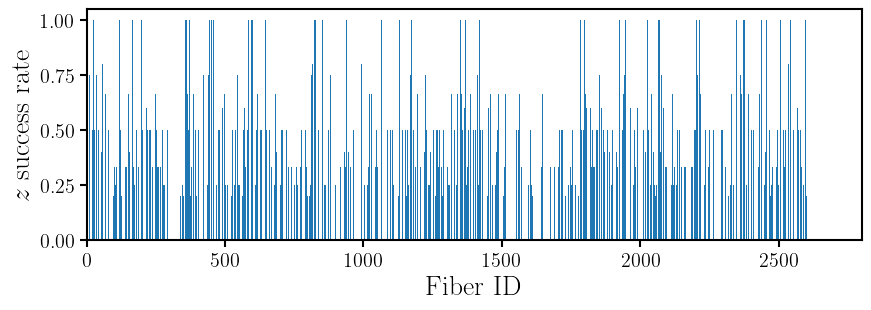

In [55]:
fig = plt.figure(figsize=(10,3))
sub = fig.add_subplot(111)
sub.bar(np.array(barhist)[:,0], np.array(barhist)[:,1]) 
sub.set_xlabel('Fiber ID', fontsize=20)
sub.set_xlim(0., 2800)
sub.set_ylabel('$z$ success rate', fontsize=20) 

In [53]:
np.mean(np.array(barhist)[:,2][~np.isnan(np.array(barhist)[:,2])])

/var/folders/w7/p2lcz8lj0m39n1ywl2_s0_j40000gp/T/ipykernel_61772/3340983736.py:1: UserWarning: Warning: converting a masked element to nan.
  np.mean(np.array(barhist)[:,2][~np.isnan(np.array(barhist)[:,2])])


np.float64(3.227469670710572)